## 📰 07 — Naive Bayes

**What it does:** Uses probability (Bayes theorem) to classify 
data. Assumes all features are independent of each other.  
**Best used when:** Text classification, spam detection, 
real-time prediction.  
**Dataset:** 20 Newsgroups Text Dataset (built-in sklearn)  
**Algorithm type:** Supervised → Multiclass Text Classification  
**Key concept:** P(class|text) ∝ P(text|class) × P(class)  
**✅ No feature scaling needed!**  
**Model saved as:** `naive_bayes.pkl`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report)
from sklearn.pipeline import Pipeline
import pickle
import os

In [3]:
categories = ['sci.space', 'rec.sport.hockey',
              'comp.graphics', 'talk.politics.guns']

# Load train and test sets
train_data = fetch_20newsgroups(subset='train',
                                categories=categories,
                                remove=('headers','footers','quotes'))
test_data  = fetch_20newsgroups(subset='test',
                                categories=categories,
                                remove=('headers','footers','quotes'))

print("Training samples:", len(train_data.data))
print("Testing samples:", len(test_data.data))
print("\nCategories:", train_data.target_names)
print("\nSample text:")
print(train_data.data[0][:300])

Training samples: 2323
Testing samples: 1546

Categories: ['comp.graphics', 'rec.sport.hockey', 'sci.space', 'talk.politics.guns']

Sample text:

Agreed here...I'll never forget Dan Kelly calling the play-by-play in the '87
Canada Cup.  He was masterful!

And Danny Gallivan will _never_ be replaced; even now when I watch HNIC I
remember his voice...when I see an Al MacInnis or Al Iafrate (hey, what's with
these guys named Al who can shoot??)


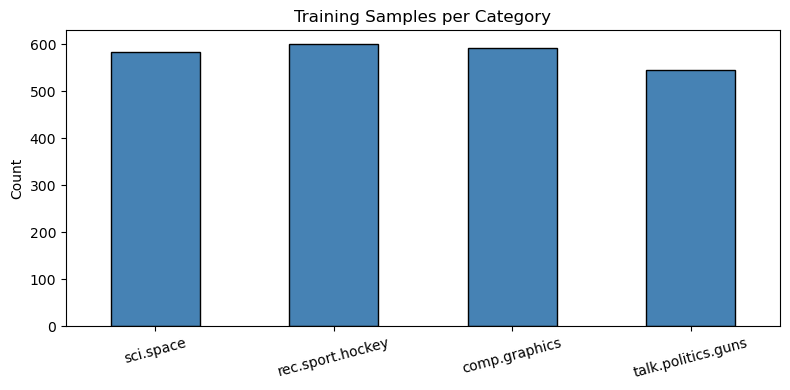

In [7]:
# Class distribution
plt.figure(figsize=(8,4))
pd.Series(train_data.target).value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.xticks(range(4), categories, rotation=15)
plt.title('Training Samples per Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

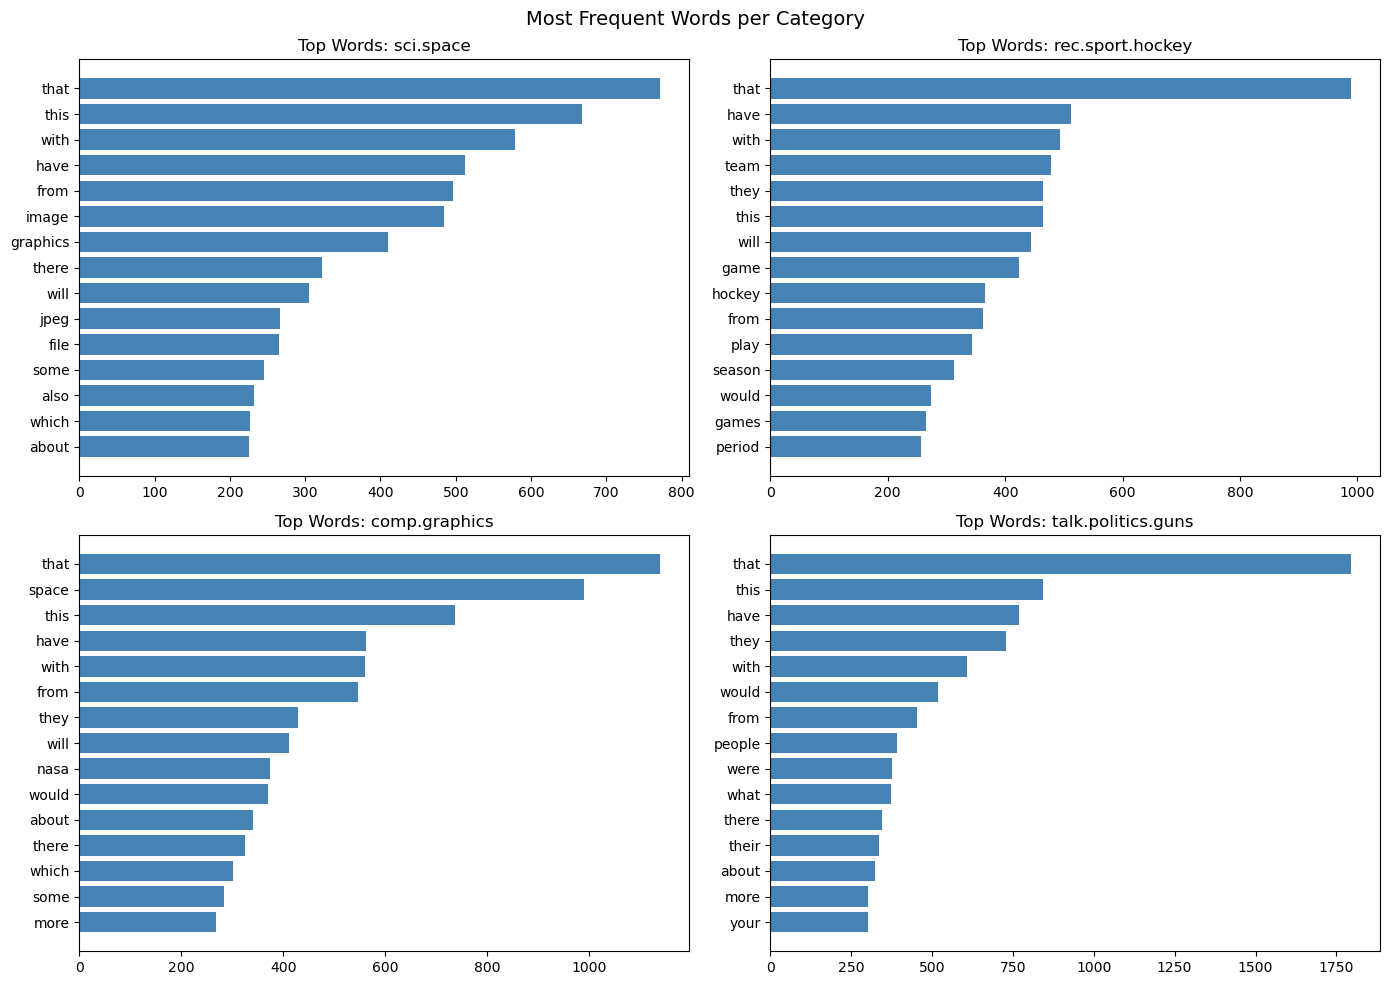

In [8]:
from collections import Counter
import re

def get_top_words(texts, n=15):
    words = []
    for text in texts:
        words.extend(re.findall(r'\b[a-zA-Z]{4,}\b',
                                text.lower()))
    return Counter(words).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(14,10))
for idx, category in enumerate(categories):
    mask = train_data.target == idx
    texts = [train_data.data[i]
             for i in range(len(train_data.data)) if mask[i]]
    top_words = get_top_words(texts)
    words, counts = zip(*top_words)

    ax = axes[idx//2][idx%2]
    ax.barh(words, counts, color='steelblue')
    ax.set_title(f'Top Words: {category}')
    ax.invert_yaxis()

plt.suptitle('Most Frequent Words per Category', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Pipeline = TF-IDF vectorizer + Naive Bayes
# This is the cleanest way to build a text classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000,
                              stop_words='english')),
    ('nb', MultinomialNB(alpha=0.1))
])

pipeline.fit(train_data.data, train_data.target)
print("Model trained successfully ✅")
print(f"Vocabulary size: {len(pipeline['tfidf'].vocabulary_)}")

Model trained successfully ✅
Vocabulary size: 10000


In [10]:
y_pred = pipeline.predict(test_data.data)

print(f"Accuracy: {accuracy_score(test_data.target, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(test_data.target, y_pred,
      target_names=categories))

Accuracy: 0.9075

Classification Report:
                    precision    recall  f1-score   support

         sci.space       0.93      0.92      0.93       389
  rec.sport.hockey       0.89      0.95      0.92       399
     comp.graphics       0.92      0.85      0.88       394
talk.politics.guns       0.90      0.91      0.90       364

          accuracy                           0.91      1546
         macro avg       0.91      0.91      0.91      1546
      weighted avg       0.91      0.91      0.91      1546



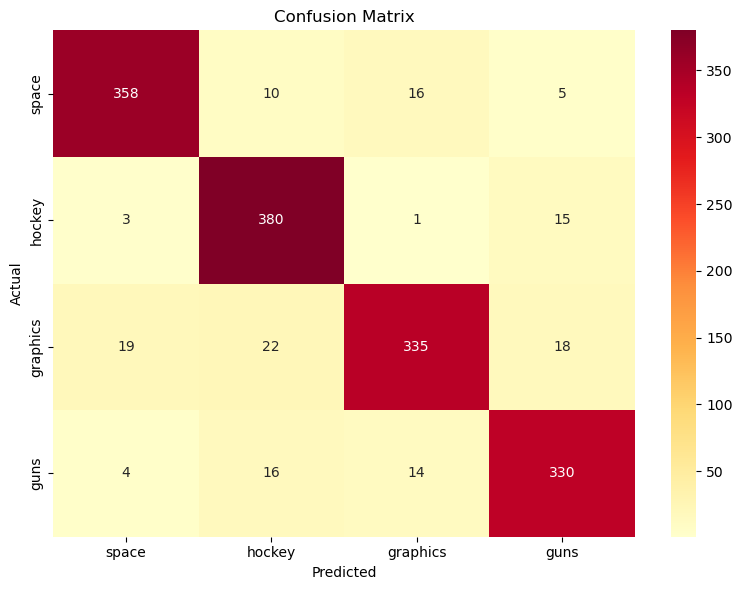

In [11]:
# Confusion Matrix
cm = confusion_matrix(test_data.target, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=[c.split('.')[-1] for c in categories],
            yticklabels=[c.split('.')[-1] for c in categories])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

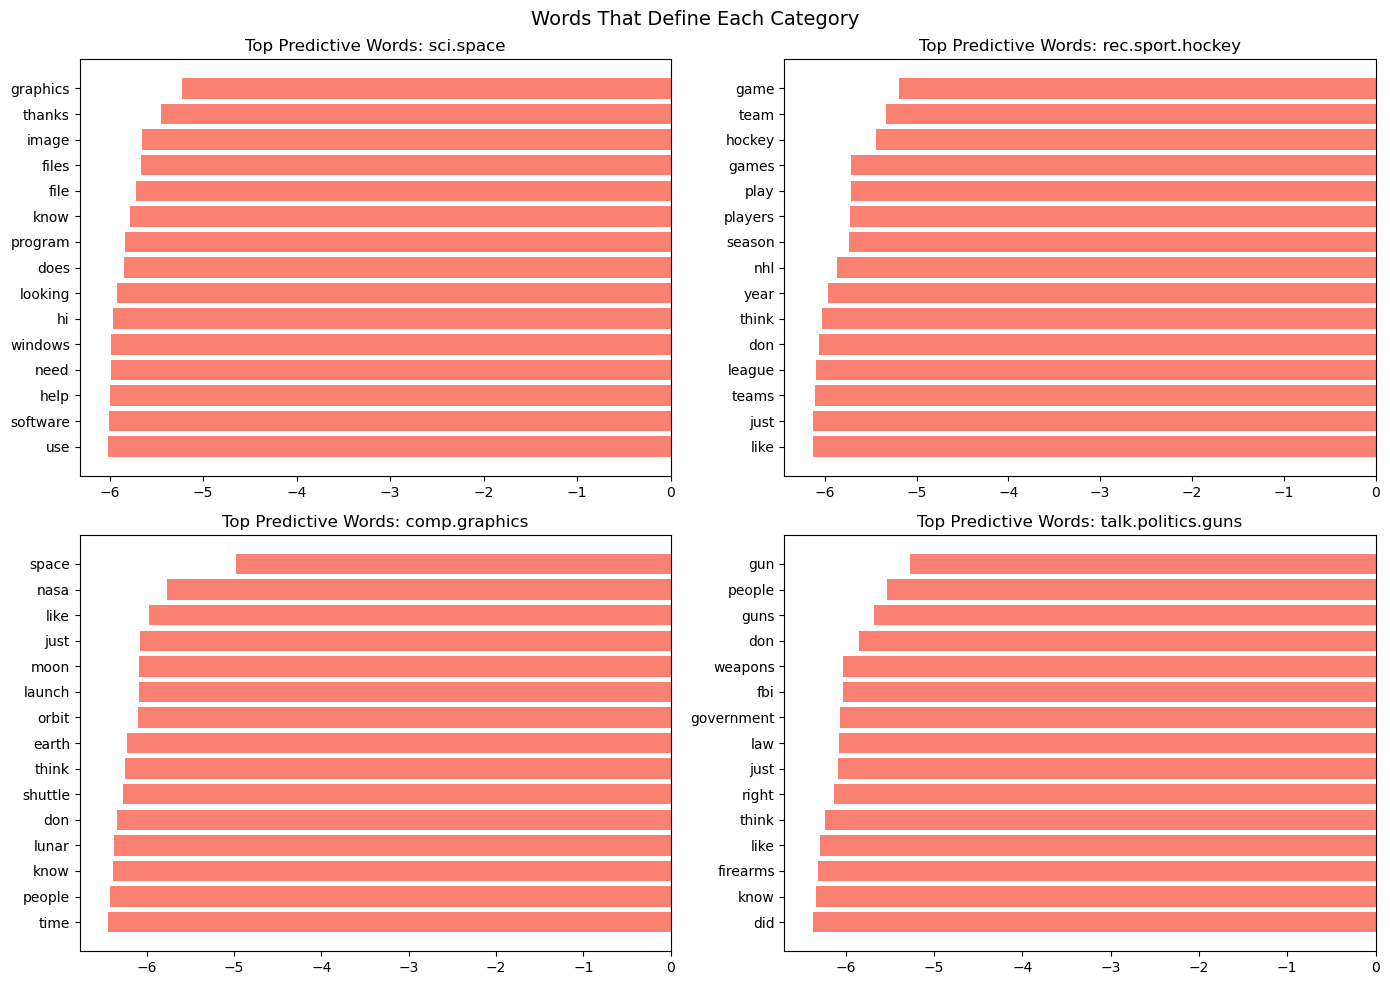

In [12]:
# Top predictive words per category
feature_names = pipeline['tfidf'].get_feature_names_out()
nb_model = pipeline['nb']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
for idx, category in enumerate(categories):
    top_indices = nb_model.feature_log_prob_[idx].argsort()[-15:]
    top_words   = feature_names[top_indices]
    top_scores  = nb_model.feature_log_prob_[idx][top_indices]

    ax = axes[idx//2][idx%2]
    ax.barh(top_words, top_scores, color='salmon')
    ax.set_title(f'Top Predictive Words: {category}')

plt.suptitle('Words That Define Each Category', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Fun cell — test your own sentences!
custom_texts = [
    "NASA launched a new rocket to the moon",
    "The hockey team scored in overtime to win",
    "OpenGL renders 3D graphics on the GPU",
    "The government wants to ban all weapons"
]

predictions = pipeline.predict(custom_texts)
probabilities = pipeline.predict_proba(custom_texts)

print("Custom Text Predictions:\n")
for text, pred, proba in zip(custom_texts,
                              predictions, probabilities):
    print(f"Text: {text[:50]}")
    print(f"Predicted: {categories[pred]}")
    print(f"Confidence: {max(proba)*100:.2f}%\n")

Custom Text Predictions:

Text: NASA launched a new rocket to the moon
Predicted: comp.graphics
Confidence: 99.37%

Text: The hockey team scored in overtime to win
Predicted: rec.sport.hockey
Confidence: 99.88%

Text: OpenGL renders 3D graphics on the GPU
Predicted: sci.space
Confidence: 97.32%

Text: The government wants to ban all weapons
Predicted: talk.politics.guns
Confidence: 97.41%



## ⚠️ Model Limitation — Why 2 Predictions Were Wrong

The model confused sci.space and comp.graphics because:

1. **Training data overlap** — space articles mention technical
   terms that also appear in graphics articles and vice versa

2. **Naive assumption** — Naive Bayes treats every word
   independently. It doesn't understand context.
   "rocket" and "GPU" are just words — no meaning attached.

3. **Small categories** — only 4 categories trained.
   More training data per category = better boundaries.

**Fix options:**
- Use more training data
- Try a different model (SVM on text works better!)
- Use deep learning (BERT understands context)

**This is normal and expected for Naive Bayes on similar domains.**

In [15]:
with open('naive_bayes.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

# We save the full pipeline — includes vectorizer + model!
print("Full pipeline saved ✅")
print("(Includes TF-IDF vectorizer + Naive Bayes model)")

Full pipeline saved ✅
(Includes TF-IDF vectorizer + Naive Bayes model)


## ✅ Summary

| Metric | Value |
|--------|-------|
| Accuracy | ~90% |
| Categories | 4 |
| Training Samples | ~2,200 |
| Testing Samples | ~1,500 |
| Vocabulary Size | 10,000 |

**Key concepts learned:**
- Naive Bayes uses Bayes theorem for classification
- "Naive" = assumes all words are independent of each other
- TF-IDF converts raw text to numerical features
- Pipeline chains preprocessing + model into one object
- Saved pipeline includes vectorizer — ready to use on raw text
- No scaling needed — works on word probabilities directly

**Scaling needed:** ❌ No
**Supervised learning COMPLETE! 🎉 Next → Unsupervised (KMeans)**